### Multiple Linear Regression

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('economic_index.csv')

In [7]:
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [11]:
# droping useless features
df.drop(columns=['Unnamed: 0','year','month'], axis=1 , inplace=True)

In [13]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [15]:
#checking any null value
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

In [21]:
df.shape

(24, 3)

In [27]:
#saperating dependent and independent variables
X = df.iloc[:,:-1]
Y = df.iloc[:,-1]

In [33]:
X.shape

(24, 2)

In [35]:
Y.shape

(24,)

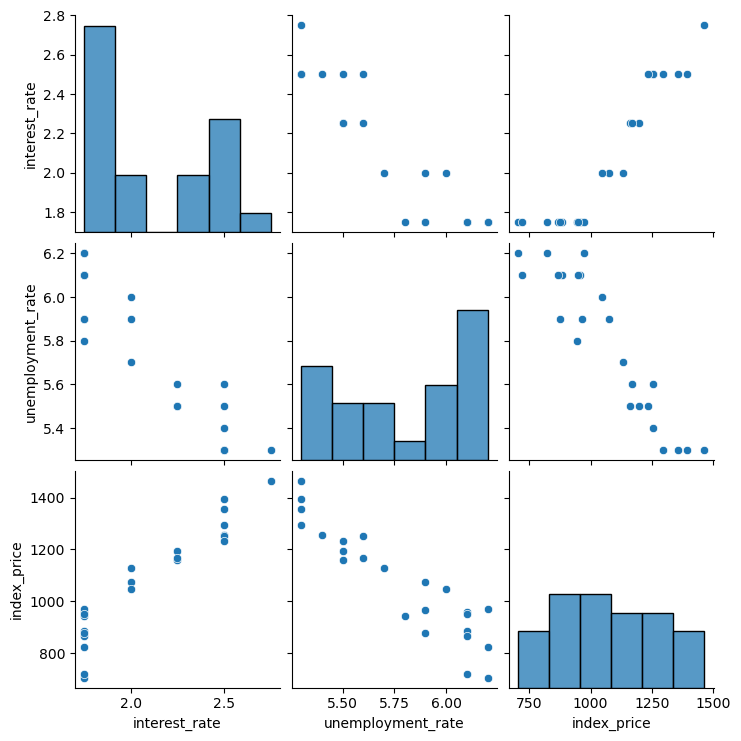

In [40]:
## visualization
sns.pairplot(df)

In [42]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


<Axes: xlabel='interest_rate', ylabel='index_price'>

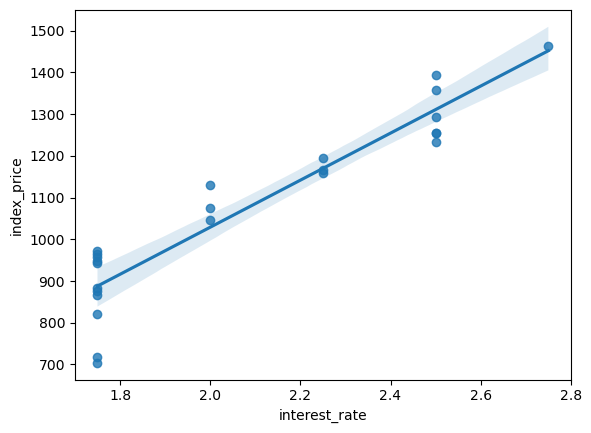

In [50]:
sns.regplot(x=df['interest_rate'],y=df['index_price'])

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

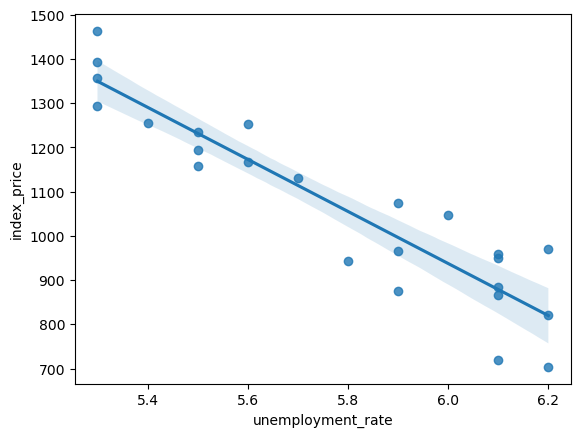

In [52]:
sns.regplot(x=df['unemployment_rate'],y=df['index_price'])

<Axes: xlabel='unemployment_rate', ylabel='interest_rate'>

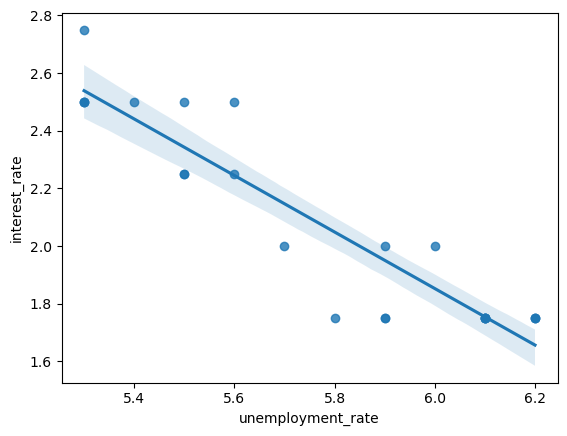

In [54]:
sns.regplot(x=df['unemployment_rate'],y=df['interest_rate'])

In [58]:
#train test split
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,Y , test_size=0.20 , random_state=42)

In [61]:
#standardization
from sklearn.preprocessing import StandardScaler

In [63]:
scaler = StandardScaler()

In [65]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [67]:
X_train

array([[ 0.55339859, -0.53244666],
       [-0.9486833 ,  0.41597395],
       [ 1.30443953, -1.48086727],
       [-0.9486833 ,  1.36439457],
       [ 1.30443953, -0.53244666],
       [ 1.30443953, -1.48086727],
       [-0.19764235,  0.73211416],
       [-0.9486833 ,  1.04825436],
       [ 1.30443953, -1.48086727],
       [ 1.30443953, -1.16472707],
       [-0.9486833 ,  1.36439457],
       [-0.9486833 ,  1.04825436],
       [-0.9486833 ,  0.41597395],
       [-0.9486833 ,  1.04825436],
       [ 0.55339859, -0.84858687],
       [-0.19764235, -0.21630646],
       [-0.9486833 ,  0.09983375],
       [-0.9486833 ,  1.04825436],
       [ 1.30443953, -0.84858687]])

In [69]:
X_test

array([[ 0.55339859, -0.84858687],
       [-0.9486833 ,  1.36439457],
       [ 2.05548048, -1.48086727],
       [-0.9486833 ,  1.04825436],
       [-0.19764235,  0.41597395]])

In [71]:
#applying model
from sklearn.linear_model import LinearRegression

In [73]:
regressor = LinearRegression()

In [75]:
regressor.fit(X_train,y_train)

LinearRegression()

In [77]:
#Cross Validation
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regressor,X_train,y_train,scoring='neg_mean_squared_error',cv=3)

In [79]:
validation_score

array([-4304.75412833, -7608.56499271, -5108.77588052])

In [81]:
np.mean(validation_score)

-5674.031667186767

In [83]:
y_pred = regressor.predict(X_test)

In [85]:
y_pred

array([1204.14403741,  821.62603274, 1406.38534684,  857.68137178,
        994.85736555])

In [87]:
y_test

8     1159
16     971
0     1464
18     884
11    1075
Name: index_price, dtype: int64

In [89]:
#preformance
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [91]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)

print('MSE: ', mse)
print('MAE: ', mae)
print('RMSE: ', rmse)

MSE:  6957.105303258842
MAE:  71.71878409976628
RMSE:  83.40926389351989


In [93]:
from sklearn.metrics import r2_score

In [97]:
score = r2_score(y_test, y_pred)
print(score)

0.8254940547158574


In [100]:
#adjusted r2
1- (1-score)*(len(y_test) -1)/(len(y_test)-X_test.shape[1]-1)

0.6509881094317147

### Assumptions

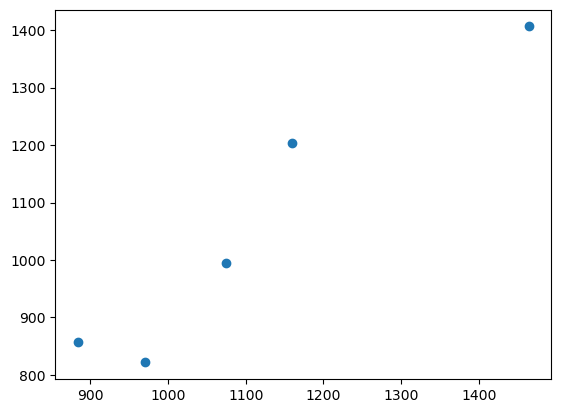

In [120]:
plt.scatter(y_test,y_pred)

In [124]:
residuals = y_test-y_pred
print(residuals)

8     -45.144037
16    149.373967
0      57.614653
18     26.318628
11     80.142634
Name: index_price, dtype: float64


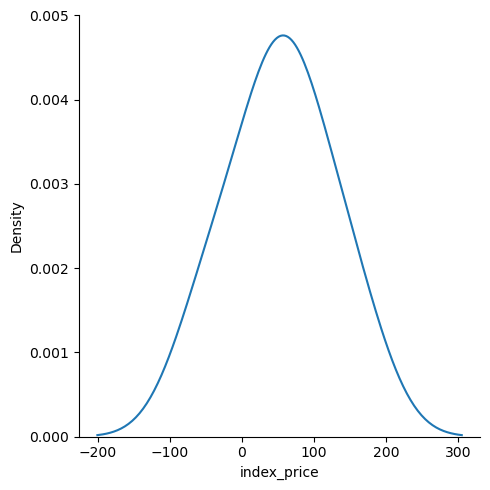

In [126]:
sns.displot(residuals,kind='kde')

In [128]:
#this is normal distribution it clears that is trained well

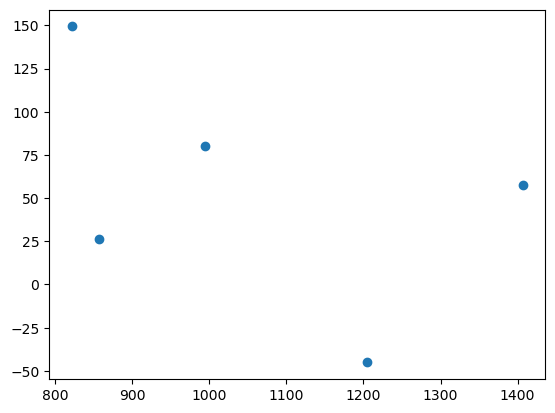

In [130]:
plt.scatter(y_pred,residuals)

In [132]:
#Using OLS Linear regression
import statsmodels.api as sm

In [134]:
model = sm.OLS(y_train,X_train).fit()

In [136]:
model.summary()

C:\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=19
  res = hypotest_fun_out(*samples, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.033
Model:                            OLS   Adj. R-squared (uncentered):             -0.081
Method:                 Least Squares   F-statistic:                             0.2916
Date:                Thu, 13 Mar 2025   Prob (F-statistic):                       0.751
Time:                        19:50:09   Log-Likelihood:                         -159.34
No. Observations:                  19   AIC:                                      322.7
Df Residuals:                      17   BIC:                                      324.6
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            86.6335    647.232      0.134      0.895   -1278.906    1452.173
x2          -114.0486    647.232     -0.176      0.862   -1479.588    1251.491
==============================================================================
Omnibus:                        0.676   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.713   Jarque-Bera (JB):                0.526
Skew:                          -0.369   Prob(JB):                        0.769
Kurtosis:                       2.656   Cond. No.                         4.82
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [138]:
regressor.coef_

array([  86.63351334, -114.04857249])